- Kyle Vogel (xbu7xh), 3/25/2026, DS 3021

#### Week 8 Lab - Linear Regression

---

##### Q0.

1. What makes a model "linear"? "Linear" in what? A model is linear in the coefficients. A model is considered linear if the model is the sum of terms. $x$ variables can be transformed by being squared, or with logarithmics, but variables like beta must stay simple terms.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed. The coefficient tells you the difference between the actual outcome that ocurred and the predicted group from the beginning. The intercept is the predicted group, and the dummy variable shifts you away from the predicted.

3. Can linear regression be used for classification? Explain why, or why not. No, linear regression should not be used for classification because it can give outputs outside of the 0 to 1 requirement for probabilities. The probability of an event ocurring cannot be less than 0% or greater than 100%, so this should not be used.

4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. This likely means that the model is overfitting, and is still learning patterns specific to the trianing that don't actually generalize with the testing data.

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$? Polynomial feature expansion creates new features and adds abilities to the functions in your mode. The second way is via binning. Binning separates the variable into different ranges and then treats each range as a category. This helps the model catch any patterns that may be nonlinear. 

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable? The intercept is the predicted value of our target variable when the other features of our model are 0. The slope coefficient for a variable shows us the relationship between unit increases with how they effect our target variable y. The coefficient for a dummy/one-hot-encoded variable is the difference in the predicted y between that given category and its baseline group.

---

##### Q1

Dataset: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("Q1_data.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [4]:
# Now let's group the rows by their borough and find the averages for price and rating
BoroughPrice = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
BoroughPrice.sort_values(by="Price", ascending=False)

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


This tells us that on average Manhattan is the most expensive neighborhood, and Brooklyn has the highest Review Scores Rating. Now let's create a KDE plot to show this:

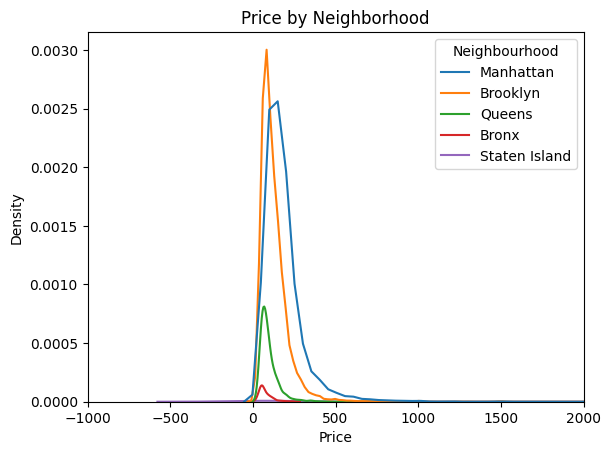

In [16]:
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price by Neighborhood")
plt.xlim(-1000, 2000)
plt.show()

Now let's also create a KDE graph for Log_Price instead of Price to more clearly see the shape of the distribution, and erase some of the outliers. The price KDE above seems to be pretty skewed to the right due to a few very high-priced listings which makes it harder to see the distributions.

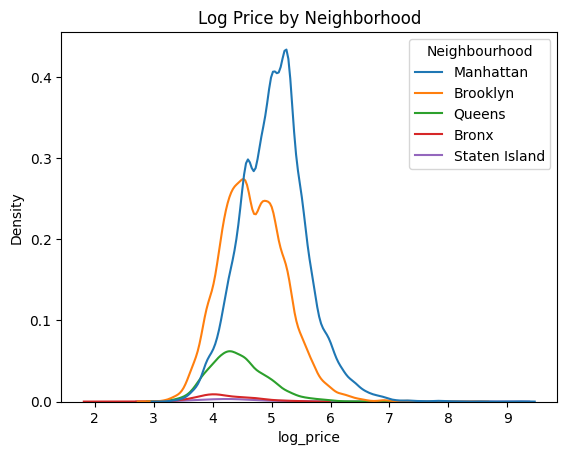

In [13]:
df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price by Neighborhood")
plt.show()

There we go. Now we can see a much more evenly distributed visual of price listings by neighborhood.

In [21]:
# Now we encode our dummy variable without dropping to to get rid of the intercept

DummyVar = pd.get_dummies(df["Neighbourhood"])
DummyVar.head()

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
0,False,False,True,False,False
1,False,True,False,False,False
2,False,False,True,False,False
3,False,True,False,False,False
4,False,False,True,False,False


In [ ]:
# Okay, now let's compare the coefficients in regression to the table that we had previously.
from sklearn.linear_model import LinearRegression

ModelBuild = LinearRegression(fit_intercept=False)
ModelBuild.fit(X, Y)

# Now we must define our variables
X = DummyVar
Y = df["Price"]

# Now let's see those coefficients
Coefficents = pd.Series(ModelBuild.coef_, index = X.columns)
print(Coefficents)

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


These are the same numbers that we calculated previously, so the model seems to be learning the average price per borough.

In [28]:
# Now let's what the coefficients are in a regression of a continous variable on one categorical

Compare = pd.DataFrame({"Regression Coefficient": Coefficents, "Average $ Per Group": BoroughPrice["Price"]})
print(Compare)

               Regression Coefficient  Average $ Per Group
Bronx                       75.276498            75.276498
Brooklyn                   127.747378           127.747378
Manhattan                  183.664286           183.664286
Queens                      96.857233            96.857233
Staten Island              146.166667           146.166667


Yeah, so we can pretty clearly see here that it is the exact same. When I regress a continuous variable on one categorical data even without an intercept it just takes the average.

In [30]:
# Now we're asked to repeat everything, except with an intercept this time
# This time you handle t he creation of the dummies differently by including the drop

DummyVar = pd.get_dummies(df["Neighbourhood"], drop_first=True)
DummyVar.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,True,False,False,False
4,False,True,False,False


In [45]:
# Next, let's fit the regression with the model like we did before, this time with the intercept
# Let's redefine X and Y to make sure they updated
X = DummyVar
Y = df["Price"]

ModelBuild = LinearRegression()
ModelBuild.fit(X, Y)

# Now we have to pass a series argument to get the coefficients and intercepts
Coefficents = pd.Series(ModelBuild.coef_, index = X.columns)
Intercept = ModelBuild.intercept_

print("Intercept: ", Intercept)
print(Coefficents)

Intercept:  75.27649769585331
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


As you can see, the intercept is 75.28, and each coefficient represents the average price of the baseline home in the given borough.

In [47]:
# We can get the coefficients in part 2 from these new coefficients by simply adding them to the intercept:

TheyAreBack = Coefficents + Intercept
TheyAreBack["Baseline"] = Intercept
TheyAreBack

Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Baseline          75.276498
dtype: float64

In [48]:
# Now for #4 we have to create a dummy variable again for neighborhood and drop because we're going to be using an intercept

X = pd.get_dummies(df[["Review Scores Rating", "Neighbourhood"]], drop_first=True)
Y = df["Price"]

In [51]:
# Now we make the 80/20 like we're asked to do through train,test,split:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

# Let's fit our model again
ModelBuild = LinearRegression()
ModelBuild.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
